# 07 — Hybrid Neural Network (Phase 2 DL Model)
## CATIVE: Company Attractiveness & Talent Intelligence Viability Engine

### Architecture Design Rationale

#### Why This Specific Architecture?
Our data has two fundamentally different modalities:
- **Text** (`top_hiring_roles`): sequential token data requiring contextual understanding
- **Tabular** (ratings, funding, flags): structured numerical data requiring feature interaction learning

A single stream cannot handle both optimally. A transformer on raw tabular data wastes capacity; an MLP on text loses sequential context.

#### Weight Initialisation — He (Kaiming) Initialisation
For layers followed by ReLU/GELU, He initialisation (He et al., 2015) sets:
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$
This prevents the *vanishing gradient problem* by keeping the variance of activations approximately constant across layers. Xavier initialisation (designed for sigmoid/tanh) would halve the variance at each layer, causing gradients to shrink exponentially in deep networks.

#### Batch Normalisation
For a mini-batch $\mathcal{B} = \{x_1, ..., x_m\}$, BatchNorm computes:
$$\hat{x}_i = \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$
It reduces *internal covariate shift* — the distribution of layer inputs shifts during training as earlier layer weights update. BatchNorm stabilises training, allows higher learning rates, and acts as a mild regulariser.

#### Dropout (Srivastava et al., 2014)
During training, each neuron is zeroed with probability $p$ and scaled by $\frac{1}{1-p}$ at inference. This forces the network to not rely on any single feature pathway, reducing co-adaptation of neurons — equivalent to training an ensemble of $2^n$ networks with shared weights.

#### AdamW Optimiser
Adam with decoupled weight decay (Loshchilov & Hutter, 2019). Unlike vanilla Adam where weight decay is entangled with the adaptive gradient, AdamW applies L2 regularisation directly to the weights:
$$\theta_{t+1} = \theta_t - \eta \left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t\right)$$
This is the standard optimiser for fine-tuning transformers.

#### Early Stopping
We monitor validation loss. If it does not improve for `patience=7` consecutive epochs, training halts and the best checkpoint is restored. This prevents overfitting without requiring us to specify the exact number of epochs in advance.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertModel, DistilBertTokenizerFast, get_linear_schedule_with_warmup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, warnings, os, copy
from sklearn.metrics import f1_score, classification_report
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LABEL_NAMES = ['Emerging', 'Growing', 'High Desirability']
NUM_CLASSES = 3
BATCH_SIZE  = 32

/Users/mk2004/Downloads/CATIVE_fixed/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: cpu


## 1. Load DL Data (from notebook 06)

In [2]:
X_tab          = np.load('../data/dl_X_tab.npy')
input_ids      = np.load('../data/dl_input_ids.npy')
attention_mask = np.load('../data/dl_attn_mask.npy')
y_enc          = np.load('../data/dl_y.npy')
idx_train      = np.load('../data/dl_idx_train.npy')
idx_val        = np.load('../data/dl_idx_val.npy')
idx_test       = np.load('../data/dl_idx_test.npy')
TAB_DIM        = int(np.load('../data/dl_tab_dim.npy')[0])

print(f'TAB_DIM: {TAB_DIM}')
print(f'Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}')

class StartupDataset(Dataset):
    def __init__(self, input_ids, attention_mask, X_tab, y):
        self.input_ids      = torch.tensor(input_ids,      dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.X_tab          = torch.tensor(X_tab,          dtype=torch.float32)
        self.y              = torch.tensor(y,               dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return {'input_ids': self.input_ids[idx], 'attention_mask': self.attention_mask[idx],
                'tabular': self.X_tab[idx], 'label': self.y[idx]}

train_ds = StartupDataset(input_ids[idx_train], attention_mask[idx_train], X_tab[idx_train], y_enc[idx_train])
val_ds   = StartupDataset(input_ids[idx_val],   attention_mask[idx_val],   X_tab[idx_val],   y_enc[idx_val])
test_ds  = StartupDataset(input_ids[idx_test],  attention_mask[idx_test],  X_tab[idx_test],  y_enc[idx_test])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

TAB_DIM: 53
Train: 700, Val: 150, Test: 150


## 2. Model Architecture

In [3]:
class CATIVEHybridNet(nn.Module):
    """
    Hybrid fusion model:
      Stream 1: DistilBERT [CLS] -> Dense(128) -> Dropout(0.3)
      Stream 2: Tabular MLP [tab_dim -> 256 -> 128 -> 64] + BatchNorm + Dropout(0.3)
      Fusion:   Concat(128, 64) -> Advanced Gated/MLP Interaction Head -> Softmax(3)
    """
    def __init__(self, tab_dim: int, num_classes: int = 3,
                 dropout: float = 0.3, freeze_bert: bool = False):
        super().__init__()

        # --- Text stream ---
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False
        BERT_DIM = 768
        self.text_proj = nn.Sequential(
            nn.Linear(BERT_DIM, 128),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # --- Tabular stream (MLP with BatchNorm) ---
        self.tab_mlp = nn.Sequential(
            nn.Linear(tab_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
        )

        # --- Advanced Fusion head ---
        FUSION_DIM = 128 + 64  # text (128) + tabular (64)
        self.fusion = nn.Sequential(
            nn.Linear(FUSION_DIM, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

        # He (Kaiming) initialisation for all linear layers
        self._init_weights()

    def _init_weights(self):
        """Apply Kaiming He initialisation to all Linear layers (except BERT)."""
        for module in [self.text_proj, self.tab_mlp, self.fusion]:
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

    def forward(self, input_ids, attention_mask, tabular):
        # Text stream
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb  = bert_out.last_hidden_state[:, 0, :]   # [CLS] token
        text_vec = self.text_proj(cls_emb)                # (B, 128)

        # Tabular stream
        tab_vec = self.tab_mlp(tabular)                   # (B, 64)

        # Fusion
        fused  = torch.cat([text_vec, tab_vec], dim=1)   # (B, 192)
        logits = self.fusion(fused)                       # (B, 3)
        return logits

model = CATIVEHybridNet(tab_dim=TAB_DIM, num_classes=NUM_CLASSES, dropout=0.3, freeze_bert=False)
model = model.to(device)

# --- Count parameters ---
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'DistilBERT params:    {sum(p.numel() for p in model.bert.parameters()):,}')
print(f'Non-BERT params:      {trainable_params - sum(p.numel() for p in model.bert.parameters()):,}')

Total parameters:     66,550,595
Trainable parameters: 66,550,595
DistilBERT params:    66,362,880
Non-BERT params:      187,715


## 3. Training Setup — AdamW + LR Warmup Scheduler

In [4]:
NUM_EPOCHS   = 15
LR_BERT      = 2e-5   # small LR for pre-trained BERT weights
LR_HEAD      = 1e-3   # larger LR for randomly initialised classification heads
WEIGHT_DECAY = 0.01
PATIENCE     = 5      # early stopping patience

# Separate param groups with different LRs (standard practice for fine-tuning)
bert_params  = list(model.bert.parameters())
head_params  = [p for p in model.parameters() if not any(p is bp for bp in bert_params)]

optimizer = torch.optim.AdamW([
    {'params': bert_params,  'lr': LR_BERT,  'weight_decay': WEIGHT_DECAY},
    {'params': head_params,  'lr': LR_HEAD,  'weight_decay': WEIGHT_DECAY},
])

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Class-weighted CrossEntropy (accounts for 1.4x imbalance)
class_counts  = np.bincount(y_enc[idx_train])
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f'Total steps: {total_steps}, Warmup steps: {warmup_steps}')
print(f'Class weights: {class_weights.cpu().numpy().round(4)}')
print(f'LR schedule: linear warmup ({warmup_steps} steps) → linear decay to 0')

Total steps: 330, Warmup steps: 33
Class weights: [1.0014 0.9971 1.0014]
LR schedule: linear warmup (33 steps) → linear decay to 0


## 4. Training Loop with Early Stopping

In [5]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids_b = batch['input_ids'].to(device)
        attn_mask_b = batch['attention_mask'].to(device)
        tabular_b   = batch['tabular'].to(device)
        labels_b    = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids_b, attn_mask_b, tabular_b)
        loss   = criterion(logits, labels_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * len(labels_b)
        preds = logits.argmax(dim=1)
        correct += (preds == labels_b).sum().item()
        total   += len(labels_b)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        input_ids_b = batch['input_ids'].to(device)
        attn_mask_b = batch['attention_mask'].to(device)
        tabular_b   = batch['tabular'].to(device)
        labels_b    = batch['label'].to(device)

        logits = model(input_ids_b, attn_mask_b, tabular_b)
        loss   = criterion(logits, labels_b)
        total_loss += loss.item() * len(labels_b)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels_b.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(all_labels), f1, all_preds, all_labels


# --- Training loop ---
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_val_loss = np.inf
patience_counter = 0
best_model_state = None

print(f'Training for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})...')
print('-' * 65)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val macro-F1: {val_f1:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, '../outputs/models/cative_hybrid_best.pt')
        print(f'           ✓ New best model saved (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1} (patience={PATIENCE} exceeded)')
            break

# Restore best model
model.load_state_dict(best_model_state)
print(f'\nBest model restored. Best val loss: {best_val_loss:.4f}')

Training for up to 15 epochs (early stopping patience=5)...
-----------------------------------------------------------------
Epoch 01/15 | Train loss: 1.4030 | Val loss: 0.8945 | Val macro-F1: 0.5321
           ✓ New best model saved (val_loss=0.8945)
Epoch 02/15 | Train loss: 1.0122 | Val loss: 0.6384 | Val macro-F1: 0.6710
           ✓ New best model saved (val_loss=0.6384)
Epoch 03/15 | Train loss: 0.7645 | Val loss: 0.5760 | Val macro-F1: 0.7330
           ✓ New best model saved (val_loss=0.5760)
Epoch 04/15 | Train loss: 0.6744 | Val loss: 0.5737 | Val macro-F1: 0.7266
           ✓ New best model saved (val_loss=0.5737)
Epoch 05/15 | Train loss: 0.6143 | Val loss: 0.5645 | Val macro-F1: 0.7548
           ✓ New best model saved (val_loss=0.5645)
Epoch 06/15 | Train loss: 0.6254 | Val loss: 0.5366 | Val macro-F1: 0.7830
           ✓ New best model saved (val_loss=0.5366)
Epoch 07/15 | Train loss: 0.5424 | Val loss: 0.5413 | Val macro-F1: 0.7510
Epoch 08/15 | Train loss: 0.5422 | Va

## 5. Training Curves

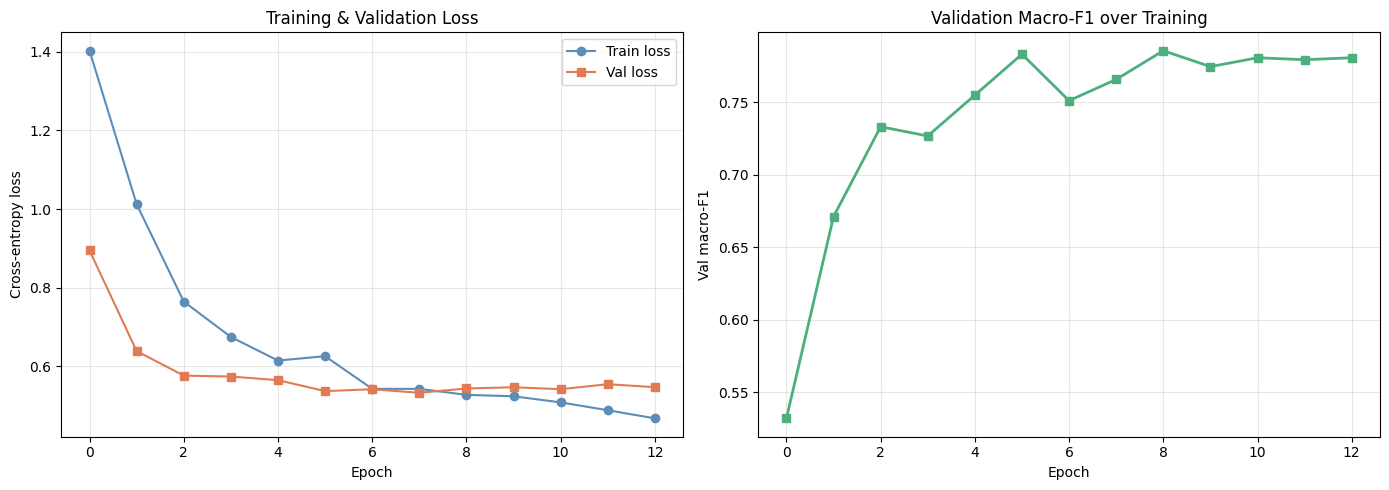

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], 'o-', color='#5B8DB8', label='Train loss')
axes[0].plot(history['val_loss'],   's-', color='#E07B54', label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_f1'], 's-', color='#4CAF7D', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val macro-F1')
axes[1].set_title('Validation Macro-F1 over Training')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/results/18_dl_training_curves.png', bbox_inches='tight')
plt.show()